# Member 3 — CatBoost
**Algorithm:** CatBoost — Categorical Boosting (Supervised)  
**Dataset:** NSL-KDD (`nsl_kdd_dataset.csv`) — 41 pre-scaled features  
**Training data:** SMOTE-balanced (from shared preprocessing)

### How CatBoost Works
CatBoost is a gradient boosting library developed by Yandex that uses
**ordered boosting** to avoid prediction shift and overfitting.
It builds symmetric (oblivious) decision trees and has strong built-in
regularisation. It typically requires less hyperparameter tuning than
XGBoost or LightGBM.

### Hyperparameter Tuning
- **Phase 1:** `RandomizedSearchCV` — wide search (40 iterations, 5-fold CV)
- **Phase 2:** `GridSearchCV` — refined search (5-fold CV)
- Scoring: **F1** macro

## 1. Import Libraries

In [12]:
# !pip install catboost shap

import pickle, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from catboost import CatBoostClassifier
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, GridSearchCV, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, roc_curve
)
from scipy.stats import uniform, randint

try:
    import shap
    SHAP_OK = True
    print('SHAP available.')
except ImportError:
    SHAP_OK = False

print('Libraries loaded.')

SHAP available.
Libraries loaded.


## 2. Load Preprocessed Data

In [13]:
with open('../data/processed/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train      = data['X_train']
X_test       = data['X_test']
y_train      = data['y_train']
y_test       = data['y_test']
feature_cols = data['feature_cols']

print(f'X_train (SMOTE) : {X_train.shape} | normal={np.sum(y_train==0)}, attack={np.sum(y_train==1)}')
print(f'X_test  (real)  : {X_test.shape}')

X_train (SMOTE) : (5670, 41) | normal=2835, attack=2835
X_test  (real)  : (886, 41)


## 3. Phase 1 — RandomizedSearchCV (Wide Search)

In [14]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    'iterations'       : randint(100, 800),
    'depth'            : randint(4, 10),
    'learning_rate'    : uniform(0.01, 0.3),
    'l2_leaf_reg'      : uniform(1, 10),
    'bagging_temperature': uniform(0, 1),
    'random_strength'  : uniform(0, 2),
    'border_count'     : [32, 64, 128, 254],
}

cat_rand = RandomizedSearchCV(
    CatBoostClassifier(eval_metric='F1', random_seed=42,
                       verbose=0, thread_count=-1),
    param_distributions=param_dist,
    n_iter=40,
    cv=cv5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
cat_rand.fit(X_train, y_train)

print(f'\nBest params (random): {cat_rand.best_params_}')
print(f'Best CV F1 (random) : {cat_rand.best_score_:.4f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params (random): {'bagging_temperature': np.float64(0.9737555188414592), 'border_count': 128, 'depth': 9, 'iterations': 786, 'l2_leaf_reg': np.float64(7.183860093330873), 'learning_rate': np.float64(0.12473859738014881), 'random_strength': np.float64(1.9664617716135764)}
Best CV F1 (random) : 0.9035


## 4. Phase 2 — GridSearchCV (Fine-Grained)

In [16]:
bp = cat_rand.best_params_

def rnd(v, step, n=1, low=0.001):
    return sorted(set([round(max(low, v + i*step), 4) for i in range(-n, n+1)]))

param_grid = {
    'iterations': [bp['iterations'] - 50, bp['iterations'], bp['iterations'] + 50],
    'depth': [bp['depth'] - 1, bp['depth']],
    'learning_rate': rnd(bp['learning_rate'], 0.02, n=1),
    'l2_leaf_reg': rnd(bp['l2_leaf_reg'], 1.0, n=1, low=1),
}

cat_grid = GridSearchCV(
    CatBoostClassifier(eval_metric='F1', random_seed=42,
                       verbose=0, thread_count=-1),
    param_grid=param_grid,
    cv=cv5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
cat_grid.fit(X_train, y_train)

best_params = cat_grid.best_params_
print(f'\nBest params (grid) : {best_params}')
print(f'Best CV F1 (grid)  : {cat_grid.best_score_:.4f}')

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best params (grid) : {'depth': 9, 'iterations': 836, 'l2_leaf_reg': np.float64(7.1839), 'learning_rate': np.float64(0.1047)}
Best CV F1 (grid)  : 0.9063


## 5. Train Final CatBoost Model

In [17]:
cat_final = CatBoostClassifier(
    **best_params,
    eval_metric='F1',
    random_seed=42,
    verbose=0,
    thread_count=-1
)
cat_final.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=False
)
print('Final CatBoost model trained.')
print(f'Parameters: {best_params}')

Final CatBoost model trained.
Parameters: {'depth': 9, 'iterations': 836, 'l2_leaf_reg': np.float64(7.1839), 'learning_rate': np.float64(0.1047)}


## 6. 5-Fold Cross-Validation

=== 5-Fold Cross-Validation ===
F1       : 0.9063  ± 0.0064
Accuracy : 0.9067 ± 0.0063
ROC-AUC  : 0.9571 ± 0.0022


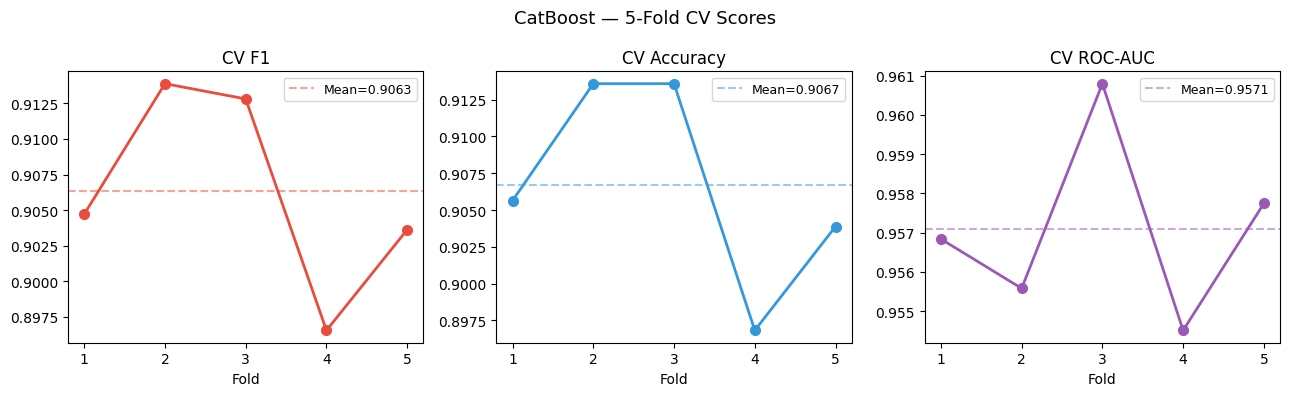

In [18]:
cv_f1  = cross_val_score(cat_final, X_train, y_train, cv=cv5, scoring='f1',       n_jobs=-1)
cv_acc = cross_val_score(cat_final, X_train, y_train, cv=cv5, scoring='accuracy', n_jobs=-1)
cv_auc = cross_val_score(cat_final, X_train, y_train, cv=cv5, scoring='roc_auc',  n_jobs=-1)

print('=== 5-Fold Cross-Validation ===')
print(f'F1       : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')
print(f'Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'ROC-AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, scores, name, color in zip(
    axes, [cv_f1, cv_acc, cv_auc],
    ['F1','Accuracy','ROC-AUC'], ['#e74c3c','#3498db','#9b59b6']
):
    ax.plot(range(1,6), scores, 'o-', color=color, lw=2, markersize=7)
    ax.axhline(scores.mean(), linestyle='--', color=color, alpha=0.5,
               label=f'Mean={scores.mean():.4f}')
    ax.set_title(f'CV {name}')
    ax.set_xlabel('Fold')
    ax.legend(fontsize=9)
    ax.set_xticks(range(1,6))
plt.suptitle('CatBoost — 5-Fold CV Scores', fontsize=13)
plt.tight_layout()
plt.savefig('cv_scores_catboost.png', dpi=150)
plt.show()

## 7. Test Set Evaluation

In [19]:
y_pred      = cat_final.predict(X_test)
y_pred_prob = cat_final.predict_proba(X_test)[:, 1]

print('=== Test Set Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Normal','Attack']))

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy  : {accuracy:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1 Score  : {f1:.4f}')
print(f'ROC-AUC   : {roc_auc:.4f}')

=== Test Set Classification Report ===
              precision    recall  f1-score   support

      Normal       0.29      0.12      0.17       177
      Attack       0.81      0.93      0.86       709

    accuracy                           0.77       886
   macro avg       0.55      0.52      0.52       886
weighted avg       0.71      0.77      0.73       886

Accuracy  : 0.7664
Precision : 0.8084
Recall    : 0.9281
F1 Score  : 0.8641
ROC-AUC   : 0.4656


## 8. Confusion Matrix & ROC Curve

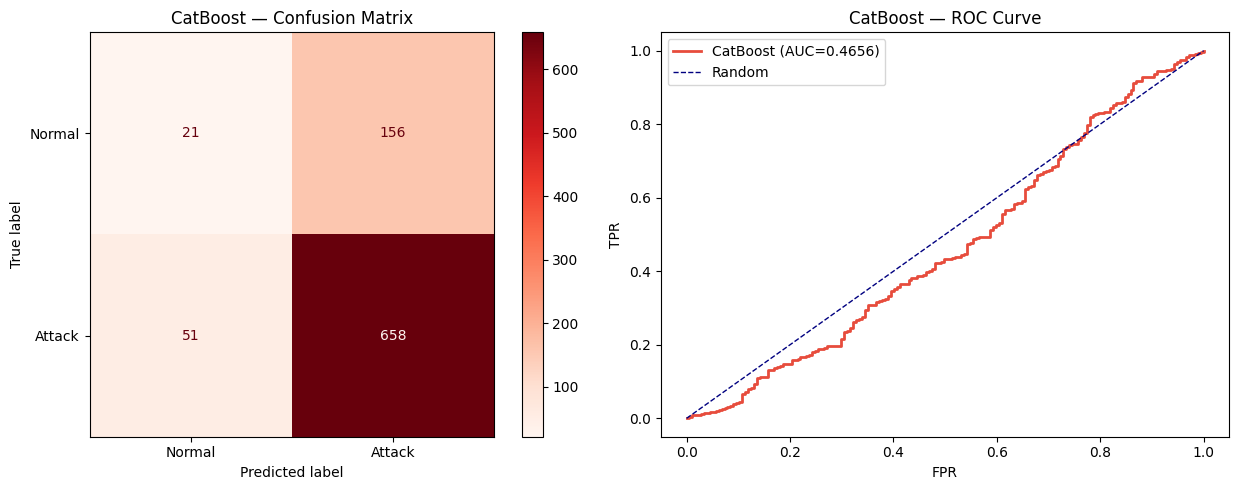

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal','Attack']).plot(
    cmap='Reds', ax=axes[0])
axes[0].set_title('CatBoost — Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'CatBoost (AUC={roc_auc:.4f})')
axes[1].plot([0,1],[0,1],'--', color='navy', lw=1, label='Random')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('CatBoost — ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.savefig('cm_roc_catboost.png', dpi=150)
plt.show()

## 9. Feature Importance

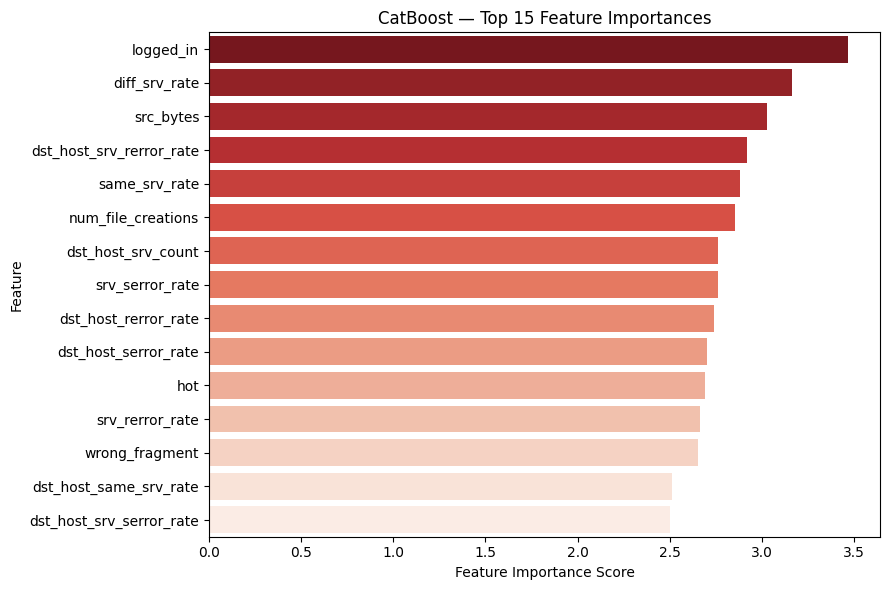

                 Feature  Importance
               logged_in    3.468030
           diff_srv_rate    3.166264
               src_bytes    3.030724
dst_host_srv_rerror_rate    2.918763
           same_srv_rate    2.883307
      num_file_creations    2.852426
      dst_host_srv_count    2.763377
         srv_serror_rate    2.762084
    dst_host_rerror_rate    2.741250
    dst_host_serror_rate    2.700873
                     hot    2.689553
         srv_rerror_rate    2.665514
          wrong_fragment    2.654884
  dst_host_same_srv_rate    2.512364
dst_host_srv_serror_rate    2.503376


In [21]:
feat_imp = cat_final.get_feature_importance()
feat_df  = pd.DataFrame({'Feature': feature_cols, 'Importance': feat_imp})\
             .sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_df.head(15), x='Importance', y='Feature',
            palette='Reds_r')
plt.title('CatBoost — Top 15 Feature Importances')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_catboost.png', dpi=150)
plt.show()
print(feat_df.head(15).to_string(index=False))

## 10. SHAP Values

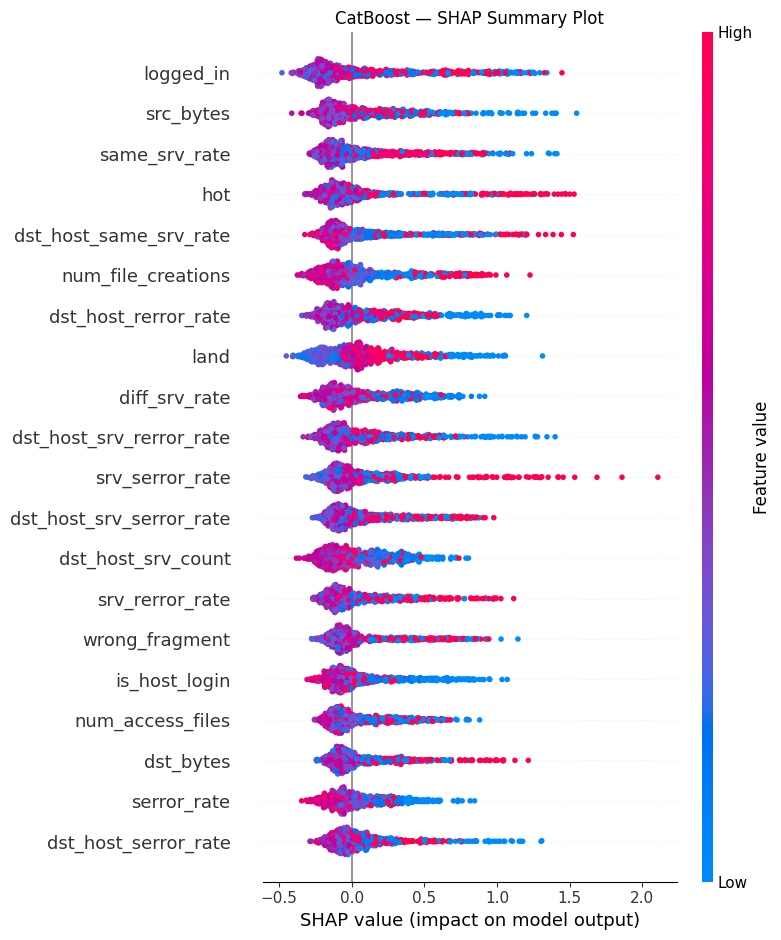

In [22]:
if SHAP_OK:
    n_shap   = min(1000, len(X_test))
    idx_shap = np.random.RandomState(42).choice(len(X_test), n_shap, replace=False)
    X_shap   = X_test[idx_shap]
    explainer   = shap.TreeExplainer(cat_final)
    shap_values = explainer.shap_values(X_shap)
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, show=False)
    plt.title('CatBoost — SHAP Summary Plot')
    plt.tight_layout()
    plt.savefig('shap_catboost.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('pip install shap')

## 11. CatBoost Training Loss Curve

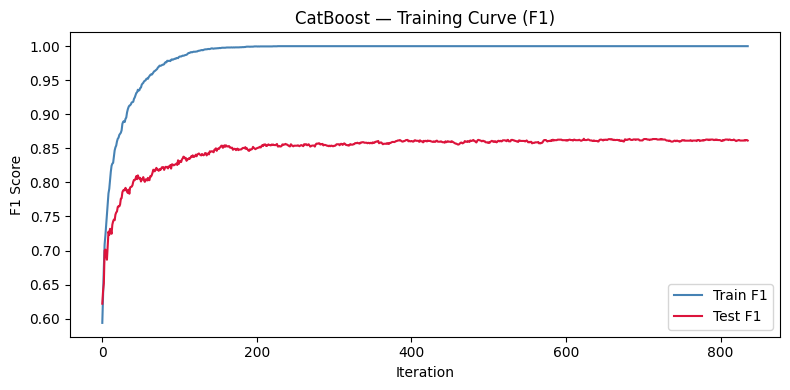

In [23]:
# Re-train with verbose to get eval log
cat_log = CatBoostClassifier(
    **best_params,
    eval_metric='F1',
    random_seed=42,
    verbose=0,
    thread_count=-1
)
cat_log.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=False)

train_f1 = cat_log.evals_result_['learn']['F1']
test_f1  = cat_log.evals_result_['validation']['F1']

plt.figure(figsize=(8, 4))
plt.plot(train_f1, label='Train F1', color='steelblue', lw=1.5)
plt.plot(test_f1,  label='Test F1',  color='crimson',   lw=1.5)
plt.xlabel('Iteration')
plt.ylabel('F1 Score')
plt.title('CatBoost — Training Curve (F1)')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curve_catboost.png', dpi=150)
plt.show()

## 12. Save Results

In [24]:
os.makedirs('../comparison', exist_ok=True)
results = pd.DataFrame([{
    'Algorithm':'CatBoost','Type':'Supervised',
    'Accuracy':round(accuracy,4),'Precision':round(precision,4),
    'Recall':round(recall,4),'F1 Score':round(f1,4),'ROC-AUC':round(roc_auc,4),
    'CV F1 Mean':round(cv_f1.mean(),4),'CV F1 Std':round(cv_f1.std(),4)
}])
print(results.to_string(index=False))
results.to_csv('../comparison/results_catboost.csv', index=False)
print('\nSaved: ../comparison/results_catboost.csv')

Algorithm       Type  Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV F1 Mean  CV F1 Std
 CatBoost Supervised    0.7664     0.8084  0.9281    0.8641   0.4656      0.9063     0.0064

Saved: ../comparison/results_catboost.csv
